# Resnet-50 训练测试

In [4]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以保证可复现性
torch.manual_seed(42)
np.random.seed(42)

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据预处理与增强
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# 数据目录
data_dir = '/remote-home/cs_acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Galaxy-Classification-Using-CNN/output_dataset'

# 加载数据集
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val', 'test']}

# 根据样本量选择合适的 batch size
batch_size = 64

dataloaders = {x: torch.utils.data.DataLoader(
                    image_datasets[x], batch_size=batch_size,
                    shuffle=(x=='train'), num_workers=4)
               for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print(f"Train samples: {dataset_sizes['train']}")
print(f"Validation samples: {dataset_sizes['val']}")
print(f"Test samples: {dataset_sizes['test']}")

# 加载预训练的 ResNet-50 并替换全连接层
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
# 学习率调度：每10个epoch将LR减少为原来的0.1
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 训练和验证函数

def train_model(model, criterion, optimizer, scheduler, num_epochs=30):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 保存最优模型
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

# 开始训练
model = train_model(model, criterion, optimizer, scheduler, num_epochs=30)
# 可选：保存模型
torch.save(model.state_dict(), 'resnet50_galaxy.pth')

# 测试集评估

def evaluate_model(model):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 分类报告
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    # 混淆矩阵可视化
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# 执行评估
evaluate_model(model)


Using device: cuda
Train samples: 43796
Validation samples: 554
Test samples: 11090
Epoch 1/30
--------------------
train Loss: 0.8288 Acc: 0.7021
val Loss: 0.7046 Acc: 0.7455

Epoch 2/30
--------------------
train Loss: 0.6430 Acc: 0.7672
val Loss: 0.6429 Acc: 0.7545

Epoch 3/30
--------------------
train Loss: 0.5885 Acc: 0.7853
val Loss: 0.6707 Acc: 0.7653

Epoch 4/30
--------------------
train Loss: 0.5488 Acc: 0.7989
val Loss: 0.5661 Acc: 0.7906

Epoch 5/30
--------------------
train Loss: 0.5131 Acc: 0.8127
val Loss: 0.6192 Acc: 0.7726

Epoch 6/30
--------------------
train Loss: 0.4817 Acc: 0.8230
val Loss: 0.6377 Acc: 0.7581

Epoch 7/30
--------------------
train Loss: 0.4502 Acc: 0.8351
val Loss: 0.6575 Acc: 0.7798

Epoch 8/30
--------------------
train Loss: 0.4164 Acc: 0.8463
val Loss: 0.6297 Acc: 0.7960

Epoch 9/30
--------------------
train Loss: 0.3902 Acc: 0.8549
val Loss: 0.7037 Acc: 0.7347

Epoch 10/30
--------------------
train Loss: 0.3541 Acc: 0.8705
val Loss: 0.697

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

Using device: cuda:1
Test classes: ['barred_spirals', 'cigar_shaped_elliptical', 'edge_on', 'in_between_elliptical', 'irregular', 'merger', 'round_elliptical', 'unbarred_spirals']
Test samples: 11090


/tmp/ipykernel_4082873/4192879581.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


✅ 测试集预测结果已保存为 resnet50_predictions.csv
Classification Report:
                          precision    recall  f1-score   support

         barred_spirals       0.84      0.85      0.84      1600
cigar_shaped_elliptical       0.73      0.88      0.80      1483
                edge_on       0.88      0.76      0.81      1600
  in_between_elliptical       0.77      0.77      0.77      1600
              irregular       0.69      0.64      0.67      1186
                 merger       0.64      0.76      0.70       421
       round_elliptical       0.78      0.91      0.84      1600
       unbarred_spirals       0.78      0.61      0.69      1600

               accuracy                           0.78     11090
              macro avg       0.76      0.77      0.76     11090
           weighted avg       0.78      0.78      0.77     11090

✅ 混淆矩阵图已保存为 confusion_matrix.png


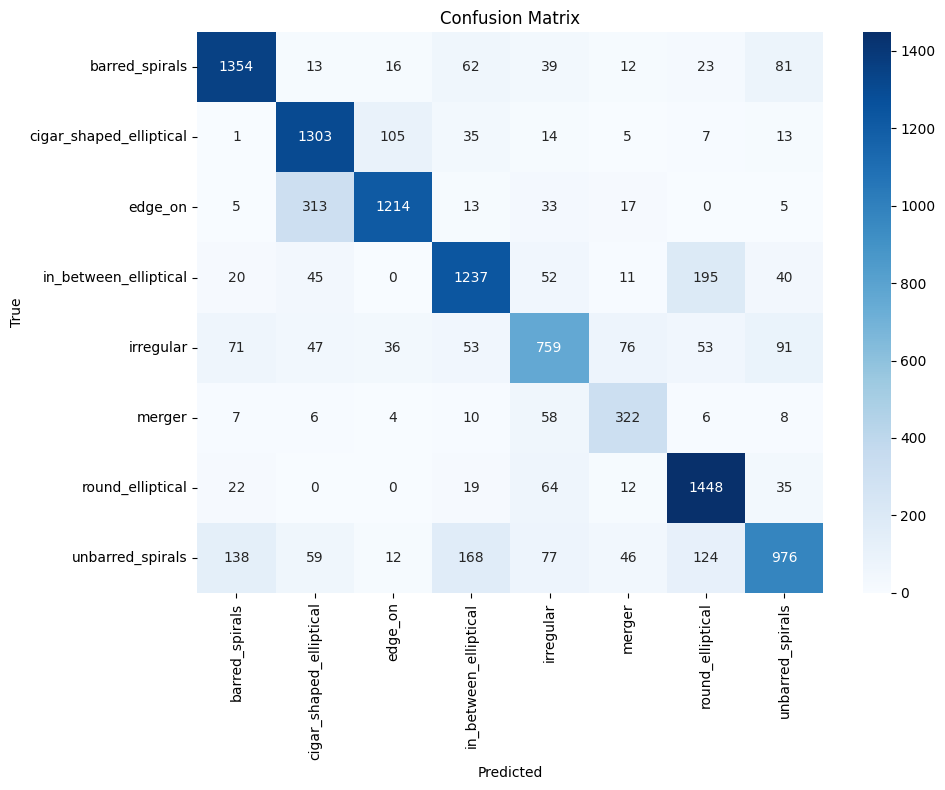

In [13]:
import os
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 设置设备
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据目录与模型路径
data_dir = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/Galaxy-Classification-Using-CNN/output_dataset'
model_path = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/resnet50_galaxy.pth'

# 图像预处理
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 加载测试集
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=data_transforms)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)
class_names = test_dataset.classes
print(f"Test classes: {class_names}")
print(f"Test samples: {len(test_dataset)}")

# 构建模型并加载参数
model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# 评估函数
def evaluate_model(model, dataloader, class_names):
    all_preds = []
    all_labels = []
    all_paths = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        # 获取图像路径列表
        all_paths = [path for path, _ in test_dataset.imgs]

    # 保存CSV文件
    df = pd.DataFrame({
        'image_path': all_paths,
        'true_label': [class_names[i] for i in all_labels],
        'predicted_label': [class_names[i] for i in all_preds]
    })
    df.to_csv('/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/resnet50_galaxy_predictions.csv', index=False)
    print("✅ 测试集预测结果已保存为 resnet50_predictions.csv")

    # 分类报告
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/resnet50_confusion_matrix.png')
    print("✅ 混淆矩阵图已保存为 confusion_matrix.png")
    plt.show()

# 执行评估
evaluate_model(model, test_loader, class_names)


In [19]:
import os
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 设置设备
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据目录与模型路径
data_dir = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/Galaxy-Classification-Using-CNN/output_dataset'
model_path = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/resnet50_galaxy.pth'

# 图像预处理
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 加载测试集
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=data_transforms)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)
class_names = test_dataset.classes
print(f"Test classes: {class_names}")
print(f"Test samples: {len(test_dataset)}")

# 构建模型并加载参数
model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

def evaluate_model(model, dataloader, dataset, class_names, output_dir):
    model.eval()
    all_preds = []
    all_labels = []
    all_paths = [path for path, _ in dataset.imgs]

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    os.makedirs(output_dir, exist_ok=True)

    # ===========================
    # 1️⃣ 保存逐样本预测 CSV
    # ===========================
    df = pd.DataFrame({
        'image_path': all_paths,
        'true_label': [class_names[i] for i in all_labels],
        'predicted_label': [class_names[i] for i in all_preds]
    })
    csv_path = os.path.join(output_dir, 'resnet50_predictions.csv')
    df.to_csv(csv_path, index=False)
    print(f"✅ Predictions saved to: {csv_path}")

    # ===========================
    # 2️⃣ Overall metrics（论文主指标）
    # ===========================
    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_precision": precision_score(all_labels, all_preds, average='macro', zero_division=0),
        "macro_recall": recall_score(all_labels, all_preds, average='macro', zero_division=0),
        "macro_f1": f1_score(all_labels, all_preds, average='macro', zero_division=0),
        "weighted_precision": precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        "weighted_recall": recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        "weighted_f1": f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    }

    print("\n=== Overall Metrics ===")
    for k, v in metrics.items():
        print(f"{k:20s}: {v:.4f}")

    metrics_path = os.path.join(output_dir, 'resnet50_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    print(f"✅ Metrics saved to: {metrics_path}")

    # ===========================
    # 3️⃣ Classification report
    # ===========================
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    print("\n=== Classification Report ===")
    print(report)

    report_path = os.path.join(output_dir, 'resnet50_classification.json')
    with open(report_path, 'w') as f:
        f.write(report)
    print(f"✅ Classification report saved to: {report_path}")

    # ===========================
    # 4️⃣ Confusion Matrix（Raw）
    # ===========================
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names,
        cmap='Blues'
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - ResNet50')
    plt.tight_layout()

    cm_path = os.path.join(output_dir, 'resnet50_confusion_matrix.png')
    plt.savefig(cm_path)
    plt.close()
    print(f"✅ Confusion matrix saved to: {cm_path}")

    # ===========================
    # 5️⃣ Confusion Matrix（Recall-normalized）
    # ===========================
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.4f',
        xticklabels=class_names,
        yticklabels=class_names,
        cmap='YlGnBu'
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Normalized Confusion Matrix (Recall)')
    plt.tight_layout()

    cm_norm_path = os.path.join(output_dir, 'resnet50_confusion_matrix_norm.png')
    plt.savefig(cm_norm_path)
    plt.close()
    print(f"✅ Normalized confusion matrix saved to: {cm_norm_path}")

# ===========================
# ===========================
if __name__ == '__main__':
    output_dir = './resnet50_evaluation_results'
    print(f"\n🚀 Starting evaluation...")
    print(f"📁 Results will be saved to: {output_dir}\n")
    
    evaluate_model(
        model=model,
        dataloader=test_loader,
        dataset=test_dataset,
        class_names=class_names,
        output_dir=output_dir
    )
    
    print("\n✅ Evaluation completed!")

Using device: cuda:1
Test classes: ['barred_spirals', 'cigar_shaped_elliptical', 'edge_on', 'in_between_elliptical', 'irregular', 'merger', 'round_elliptical', 'unbarred_spirals']
Test samples: 11090

🚀 Starting evaluation...
📁 Results will be saved to: ./resnet50_evaluation_results



/tmp/ipykernel_4082873/2067553681.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


✅ Predictions saved to: ./resnet50_evaluation_results/resnet50_predictions.csv

=== Overall Metrics ===
accuracy            : 0.7766
macro_precision     : 0.7641
macro_recall        : 0.7721
macro_f1            : 0.7640
weighted_precision  : 0.7801
weighted_recall     : 0.7766
weighted_f1         : 0.7743
✅ Metrics saved to: ./resnet50_evaluation_results/resnet50_metrics.json

=== Classification Report ===
                         precision    recall  f1-score   support

         barred_spirals     0.8368    0.8462    0.8415      1600
cigar_shaped_elliptical     0.7296    0.8786    0.7972      1483
                edge_on     0.8753    0.7588    0.8129      1600
  in_between_elliptical     0.7746    0.7731    0.7739      1600
              irregular     0.6925    0.6400    0.6652      1186
                 merger     0.6427    0.7648    0.6985       421
       round_elliptical     0.7802    0.9050    0.8380      1600
       unbarred_spirals     0.7814    0.6100    0.6852      1600

   

# densenet121-训练测试

In [10]:
import os
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

# ✅ 设置设备
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ 数据目录
data_dir = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/Galaxy-Classification-Using-CNN/output_dataset'

# ✅ 图像预处理
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# ✅ 加载数据
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=(x == 'train'), num_workers=4)
    for x in ['train', 'val', 'test']
}
class_names = image_datasets['train'].classes
print(f"Detected classes: {class_names}")

# ✅ 初始化模型
model = models.densenet121(pretrained=True)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# ✅ 损失函数与优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ✅ 训练函数
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print('-' * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    model.load_state_dict(best_model_wts)
    return model

# ✅ 训练模型
model = train_model(model, criterion, optimizer, scheduler, num_epochs=30)

# ✅ 保存模型权重
save_path = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/densenet121_best.pth'
torch.save(model.state_dict(), save_path)
print(f"\n✅ 模型权重已保存至: {save_path}")

# ✅ 测试集评估函数
def evaluate_model(model, dataloader, dataset, class_names, output_dir):
    model.eval()
    all_preds = []
    all_labels = []
    all_paths = [path for path, _ in dataset.imgs]

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 保存CSV
    df = pd.DataFrame({
        'image_path': all_paths,
        'true_label': [class_names[i] for i in all_labels],
        'predicted_label': [class_names[i] for i in all_preds]
    })
    csv_path = os.path.join(output_dir, 'densenet121_predictions.csv')
    df.to_csv(csv_path, index=False)
    print(f"✅ 预测结果已保存为: {csv_path}")

    # 分类报告
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    print("Classification Report:\n", report)

    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - DenseNet121')
    plt.tight_layout()
    cm_path = os.path.join(output_dir, 'densenet121_confusion_matrix.png')
    plt.savefig(cm_path)
    print(f"✅ 混淆矩阵已保存为: {cm_path}")
    plt.close()

# ✅ 评估模型
output_dir = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs'
os.makedirs(output_dir, exist_ok=True)
evaluate_model(model, dataloaders['test'], image_datasets['test'], class_names, output_dir)


Using device: cuda:1
Detected classes: ['barred_spirals', 'cigar_shaped_elliptical', 'edge_on', 'in_between_elliptical', 'irregular', 'merger', 'round_elliptical', 'unbarred_spirals']

Epoch 1/30
--------------------
Train Loss: 0.8246 Acc: 0.6997
Val Loss: 0.6125 Acc: 0.7690

Epoch 2/30
--------------------
Train Loss: 0.6061 Acc: 0.7800
Val Loss: 0.5952 Acc: 0.7581

Epoch 3/30
--------------------
Train Loss: 0.5379 Acc: 0.8030
Val Loss: 0.5894 Acc: 0.7690

Epoch 4/30
--------------------
Train Loss: 0.4772 Acc: 0.8255
Val Loss: 0.5459 Acc: 0.7960

Epoch 5/30
--------------------
Train Loss: 0.4205 Acc: 0.8482
Val Loss: 0.6055 Acc: 0.7690

Epoch 6/30
--------------------
Train Loss: 0.2723 Acc: 0.9076
Val Loss: 0.5628 Acc: 0.7996

Epoch 7/30
--------------------
Train Loss: 0.2228 Acc: 0.9274
Val Loss: 0.5665 Acc: 0.7852

Epoch 8/30
--------------------
Train Loss: 0.1921 Acc: 0.9379
Val Loss: 0.5934 Acc: 0.7870

Epoch 9/30
--------------------
Train Loss: 0.1626 Acc: 0.9500
Val Loss